In [2]:
#Loads/Imports
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import argparse
import glob
import os
import numpy as np
import pandas as pd
from sklearn import decomposition
from sklearn.decomposition import PCA, IncrementalPCA
import torch
import cv2
from cv2 import imwrite
from PIL import Image
from IPython.display import display
from imageio import imsave
import tifffile



## P1
Load all images and overlay Rectangles onto separate images
  
   Sub Part: Use Positive grasp rectangle coordinates to generate masks for P3

In [18]:
#P1
# Loading Images and Data
# Loop through all image files in the folder, all pngs, tiffs, and masks are all indexed to align

folder_path = "/content/hw2/data/02/"
files= os.listdir(folder_path) #OS is an operating system object, listdir is a file objkect
files=sorted(files) #sorts in alphabetical order
images=[] #Declare images as an empty object
images_pos=[]
images_neg=[]
neg_rect=[]
pos_rect=[]
masks=[]
RGBDtiff=[]
j=0


for filename in files:
    filename = folder_path + str(filename).strip()
    #print(filename)

    if filename.endswith((".txt")):  #look for png files
        if ("cneg") in filename:
         #print("cneg")
            if os.path.getsize(filename) == 0:
                 print(f"File '{filename}' is empty.")
            else:
                neg_rect= pd.read_csv(filename, delimiter=r'\s+', header=None, engine='python')
                neg_rect = neg_rect.to_numpy()
        elif ("cpos") in filename:
          #print("cpos")
            if os.path.getsize(filename) == 0:
                 print(f"File '{filename}' is empty.")
            else:
                pos_rect= pd.read_csv(filename,delimiter=r'\s+', header=None, engine='python')
                pos_rect = pos_rect.to_numpy()

        else:
          #print("point cloud")
          continue


    elif filename.endswith((".png")):  #look for png files
        #print("png")
        img = mpimg.imread(filename)  # Read the image

        images.append(img)
        img_pos = mpimg.imread(filename)  # Read the image for positive rectangle overlay
        images_pos.append(img_pos)
        img_neg= mpimg.imread(filename)  # Read the image for negative rectangle overlay
        images_neg.append(img_neg)
        mask = np.zeros(images_pos[j].shape[:2], dtype=np.uint8) #Initialize Mask
        for i in range(0,len(pos_rect),4):
          #Plot Rectangles on Images
          rectangle_pts = np.array([[pos_rect[i,0],pos_rect[i,1]], [pos_rect[i+1,0],pos_rect[i+1,1]], [pos_rect[i+2,0],pos_rect[i+2,1]], [pos_rect[i+3,0],pos_rect[i+3,1]]], np.int32)
          rectangle_pts = rectangle_pts.reshape((-1, 1, 2))
          cv2.polylines(images_pos[j], [rectangle_pts], isClosed=True, color=(255, 0, 0), thickness=1)
          #Save Positive Rectangle Masks for use in P3
          polygon = rectangle_pts
          cv2.fillPoly(mask, [polygon], 255)
        masks.append(mask)
        for i in range(0,len(neg_rect),4):
          #Plot Rectangles on Images
          rectangle_pts = np.array([[neg_rect[i,0],neg_rect[i,1]], [neg_rect[i+1,0],neg_rect[i+1,1]], [neg_rect[i+2,0],neg_rect[i+2,1]], [neg_rect[i+3,0],neg_rect[i+3,1]]], np.int32)
          rectangle_pts = rectangle_pts.reshape((-1, 1, 2))
          cv2.polylines(images_neg[j], [rectangle_pts], isClosed=True, color=(255, 0, 0), thickness=1)
        j=j+1
        #print(j)
        continue

    elif filename.endswith(("_RGBD.tiff")):  #look for tiff files, Chris's Code here for loading tiff files
        #print("")
        #img_path = os.path.join(folder_path, filename)
        #print("tiff")
        tiffin = cv2.imread(filename, cv2.IMREAD_UNCHANGED)
        RGBDtiff.append(tiffin)
        continue

print("Loaded", len(images), "images")




Loaded 29 images


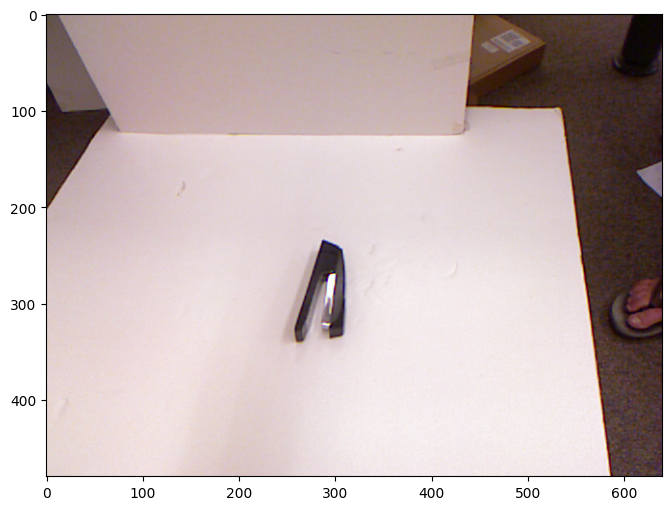

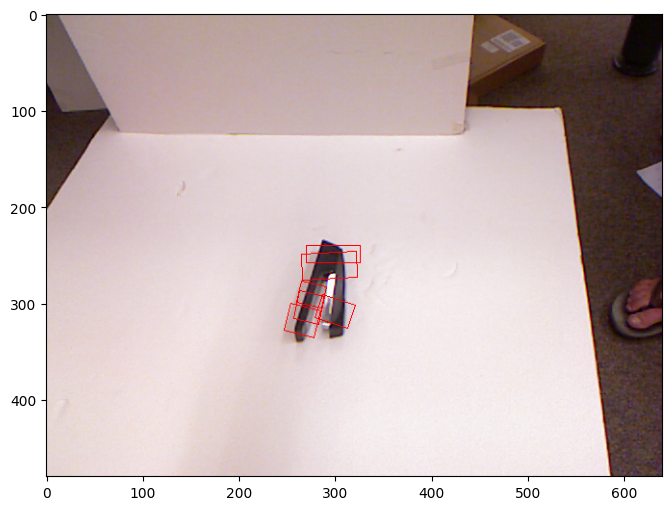

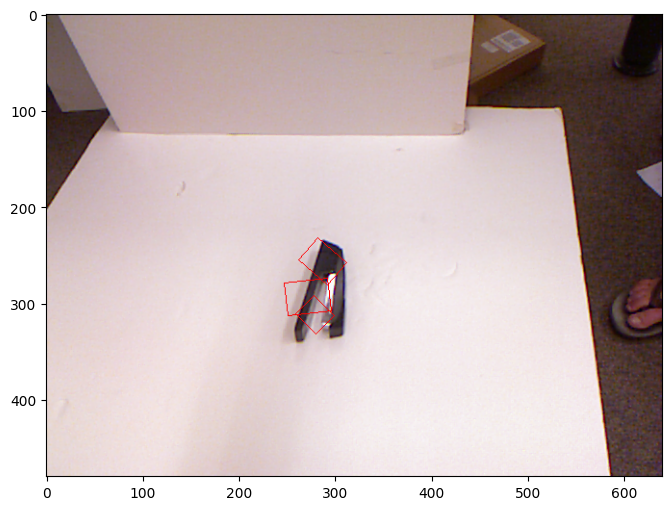

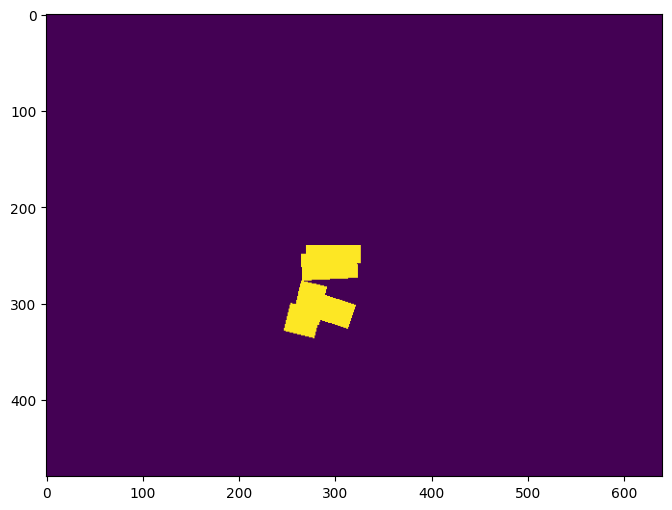

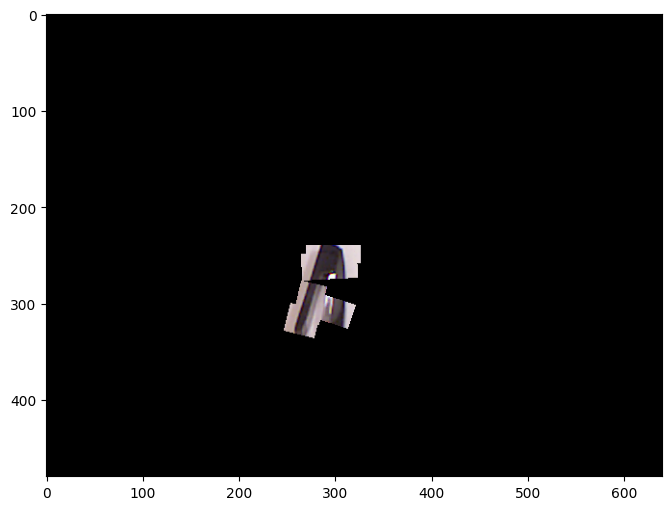

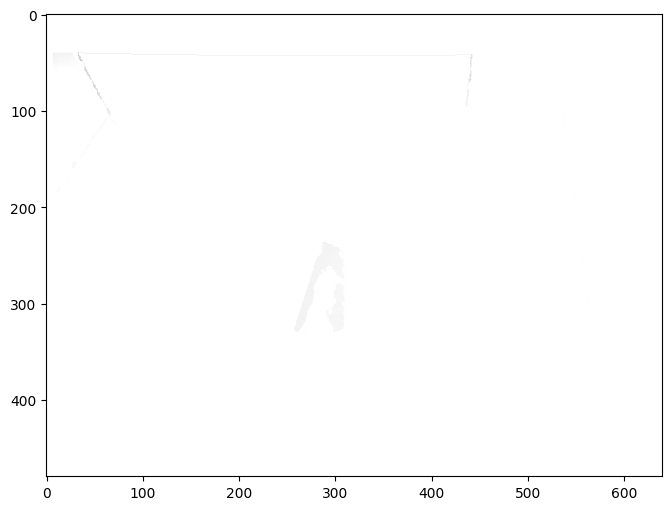

In [19]:
#P1 Inspect Dataset (when changing indices ensure they all match)
plt.figure(figsize=(12, 6))
plt.imshow(images[5])
plt.show()
plt.figure(figsize=(12, 6))
plt.imshow(images_pos[5])
plt.show()
plt.figure(figsize=(12, 6))
plt.imshow(images_neg[5])
plt.show()
plt.figure(figsize=(12, 6))
plt.imshow(masks[5])
plt.show()
plt.figure(figsize=(12, 6))
#Trim Image using Mask
extracted = cv2.bitwise_and(images[5], images[5], mask=masks[5])
plt.imshow(extracted)
plt.show()
plt.figure(figsize=(12, 6))
plt.imshow(RGBDtiff[5])


## P2 Create Depth map images using point cloud data and RGB files

In [ ]:
#P2
#Imports for custom code
import sys
sys.path.append('/content/HW2/data/02') # Allows access to python files uploaded to Jupyter environment
import image
from image import DepthImage

## From image.py it calls the DepthImage class and creates RGB and Depth Images

Note: The class "DepthImage" was modified so that it created RGB and Depth images.
Original Code Source: https://github.com/skumra/robotic-grasping/blob/master/utils/dataset_processing/image.py

In [ ]:

path = './data/01/'
pcds = glob.glob(os.path.join(path, 'pcd[0-9][0-9][0-9][0-9].txt'))  # Matches 'pcdXXXX.txt'
pcds.sort()

for pcd in pcds:
    di, rgb_img = DepthImage.from_pcd(pcd, (480, 640))

    # Save depth image
    depth_of_name = pcd.replace('.txt', '_depth.tiff')
    imwrite(depth_of_name, di.img.astype(np.float32))

    # Save RGB image
    rgb_of_name = pcd.replace('.txt', '_rgb.png')
    imwrite(rgb_of_name, rgb_img)


## File verification

1) verify that the file exists
2) get information about file

In [ ]:
file_path = "/content/HW2/data/02/pcd0100_depth.tiff"
if os.path.exists(file_path):
    print("File exists!")
else:
    print("File not found.")

File exists!


In [ ]:
try:
    with tifffile.TiffFile(file_path) as tif:
        print(tif.pages)  # Number of pages
        print("Image shape:", tif.pages[0].shape)  # Shape of first page
        print("Data type:", tif.pages[0].dtype)  # Data type
        print("Compression:", tif.pages[0].compression)  # Compression method
except Exception as e:
    print("Error:", e)

<tifffile.TiffPages @1228808>
Image shape: (480, 640)
Data type: float32
Compression: 1


# Combine RGB With Depth Images
The previous code created 2 different images one was an RGB and the other one was a depth image. I came to the realization that I needed to combine these two into one single 4-channel TIFF file. The following function does that.

In [ ]:
import tifffile
import glob



def save_rgbd_as_tiff(rgb_img, depth_img, filename):
    """
    Save RGB-D as a multi-channel TIFF file.
    """
    # Ensure depth image is loaded and has the correct shape
    if depth_img is None or depth_img.size == 0:
        raise ValueError("Depth image is empty or not loaded correctly!")

    if rgb_img.shape[:2] != depth_img.shape:
        raise ValueError(f"Shape mismatch! RGB: {rgb_img.shape}, Depth: {depth_img.shape}")

    depth_img = depth_img.astype(np.float32)  # Keep full precision

    # Ensure depth is 3D by expanding dimensions
    depth_img = np.expand_dims(depth_img, axis=-1)  # Shape: (480, 640, 1)

    # Concatenate RGB and Depth into a single image (H, W, 4)
    rgbd_img = np.concatenate((rgb_img, depth_img), axis=-1)

    # Save as TIFF
    tifffile.imwrite(filename, rgbd_img)


path = './data/01/'
pcds = glob.glob(os.path.join(path, 'pcd[0-9][0-9][0-9][0-9].txt'))  # Matches 'pcdXXXX.txt'
pcds.sort()

#print(pcds)
output_dir = './data/02/'
#os.makedirs(output_dir, exist_ok=True)  # Create the directory if it doesn't exist


for pcd in pcds:
    pcd_path = os.path.join('./data/01/', pcd)
    rgb_name = pcd.replace('.txt', '_rgb.png')
    depth_name = pcd.replace('.txt', '_depth.tiff')

    # New filename for the TIFF file in ./data/02/
    filename = os.path.join(output_dir, os.path.basename(pcd.replace('.txt', '_RGBD.tiff')))
    #print(filename)
    #print(rgb_name)
    rgb_img = cv2.imread(rgb_name)
    depth_img = cv2.imread(depth_name, cv2.IMREAD_UNCHANGED)
    #print(depth_img)
    save_rgbd_as_tiff(rgb_img, depth_img, filename)


## Check Depth Map outputs

##P3
Extract Sub Patches using Grasping Rectangles as Template

Generate Sub Patches with YUV and Depth Map Features

## Convert RGB Components  to YUV

In [20]:
#P3/ P4
#####################YUV Conversion
import cv2
import numpy as np
import tifffile
import pandas as pd
#####################Loop using RGBD variable and test
rgbd=[]
yuvmat=[]
depthmat=[]

i=0
for items in RGBDtiff:
  # Load the 4-channel RGB-D image from TIFF
  rgbd = RGBDtiff[i]  # Ensure this is a 4-channel TIFF
  print("Loaded RGB-D shape:", rgbd.shape)  # Expected shape: (480, 640, 4)
  rgb= rgbd[:, :, :3]
  yuv = cv2.cvtColor(rgb, cv2.COLOR_BGR2YUV)  # Convert RGB to YUV
  yuvmat.append(yuv)
  # Extract depth (4th channel)

  depth = rgbd[:, :, 3]  # Last channel is Depth
  depthmat.append(depth)

  print("YUV shape:", yuvmat[i].shape)  # Should be (480, 640, 3)
  print("Depth shape:", depth[i].shape)  # Should be (480, 640)
  i=i+1


Loaded RGB-D shape: (480, 640, 4)
YUV shape: (480, 640, 3)
Depth shape: (640,)
Loaded RGB-D shape: (480, 640, 4)
YUV shape: (480, 640, 3)
Depth shape: (640,)
Loaded RGB-D shape: (480, 640, 4)
YUV shape: (480, 640, 3)
Depth shape: (640,)
Loaded RGB-D shape: (480, 640, 4)
YUV shape: (480, 640, 3)
Depth shape: (640,)
Loaded RGB-D shape: (480, 640, 4)
YUV shape: (480, 640, 3)
Depth shape: (640,)
Loaded RGB-D shape: (480, 640, 4)
YUV shape: (480, 640, 3)
Depth shape: (640,)
Loaded RGB-D shape: (480, 640, 4)
YUV shape: (480, 640, 3)
Depth shape: (640,)
Loaded RGB-D shape: (480, 640, 4)
YUV shape: (480, 640, 3)
Depth shape: (640,)
Loaded RGB-D shape: (480, 640, 4)
YUV shape: (480, 640, 3)
Depth shape: (640,)
Loaded RGB-D shape: (480, 640, 4)
YUV shape: (480, 640, 3)
Depth shape: (640,)
Loaded RGB-D shape: (480, 640, 4)
YUV shape: (480, 640, 3)
Depth shape: (640,)
Loaded RGB-D shape: (480, 640, 4)
YUV shape: (480, 640, 3)
Depth shape: (640,)
Loaded RGB-D shape: (480, 640, 4)
YUV shape: (480, 6

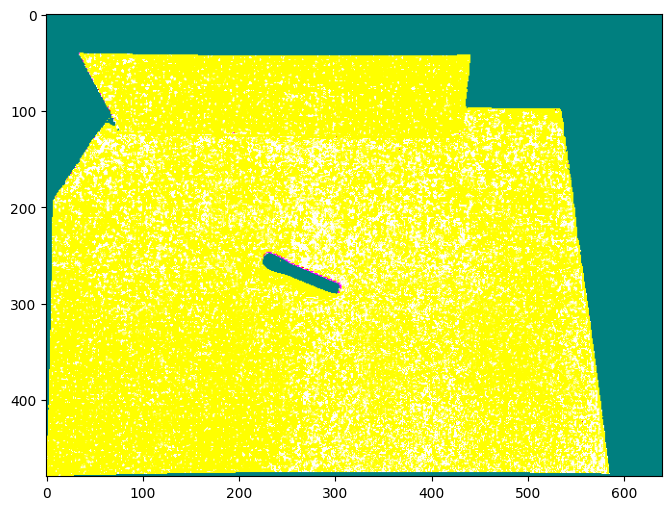

In [21]:
##Visualize YUV to verify
plt.figure(figsize=(12, 6))
plt.imshow(yuvmat[20])

##P3/P4
P3 Extract Grasp Rectangle Intersection with Mask

P4 Perform PCA on the Results

In [22]:
#P3/ P4
#P3
##############Grasp Rectangle Extraction using Masks
extracts=[]
extractsyuv=[]
cropped_images = []
cropped_images_yuv=[]
image_recon = []
# Load the saved 4-channel RGB-D image
#Reference tiff array for this
i=0
for items in RGBDtiff:
  rgbd_new = RGBDtiff[i]

  # Extract RGB and Depth for visualization
  rgb_new = rgbd_new[:, :, :3]
  depth_new = rgbd_new[:, :, 3]

  #Sub-Patch Extraction: Use Masks saved from P1
  extracted = cv2.bitwise_and(depth_new, depth_new, mask=masks[i])
  extractedyuv= cv2.bitwise_and(yuvmat[i], yuvmat[i], mask=masks[i])
  extracts.append(extracted)
  extractsyuv.append(extractedyuv)
  #Contour Cleanup
  #Trimming and Visualization

  #Trim Image with Mask Contours to limit Mask effect on PCA

  contours, _ = cv2.findContours(masks[i], cv2.RETR_LIST , cv2.CHAIN_APPROX_NONE)

  # Grab the largest contour is the ROI (lossy, does not always get all grasp rectangles in cropped image)
  c = max(contours, key=cv2.contourArea)

  # Get the bounding box coordinates
  x, y, w, h = cv2.boundingRect(c)
  #Crop Image
  crop= extracted[y:y+h, x:x+w]
  cropyuv= extractedyuv[y:y+h, x:x+w]
  cropped_images.append(crop)
  cropped_images_yuv.append(cropyuv)

  #P4
  #PCA Ops
  pca = PCA()
  pca.fit(cropped_images[i])
  # Getting the cumulative variance
  var_cumu = np.cumsum(pca.explained_variance_ratio_)*100

  # How many PCs explain 99% of the variance?
  k = np.argmax(var_cumu>99)

  #Perform PCA and generate reconstructed images
  ipca = IncrementalPCA(whiten=True, n_components=k) #set value to k (99% variance) so process can be looped
  recon = ipca.inverse_transform(ipca.fit_transform(cropped_images[i]))
  image_recon.append(recon)

  i=i+1

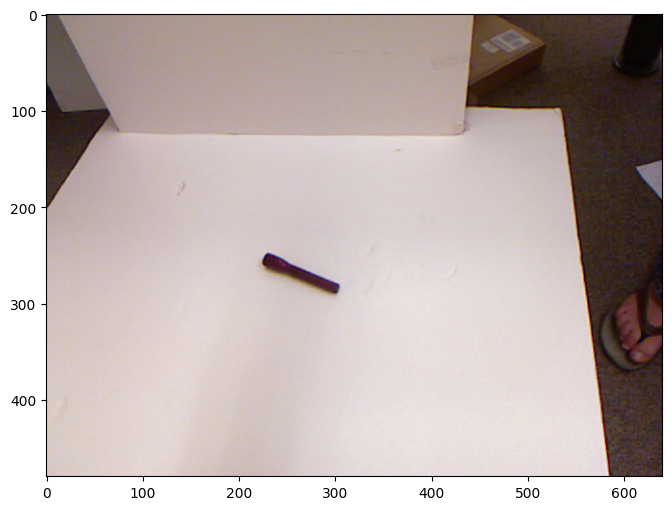

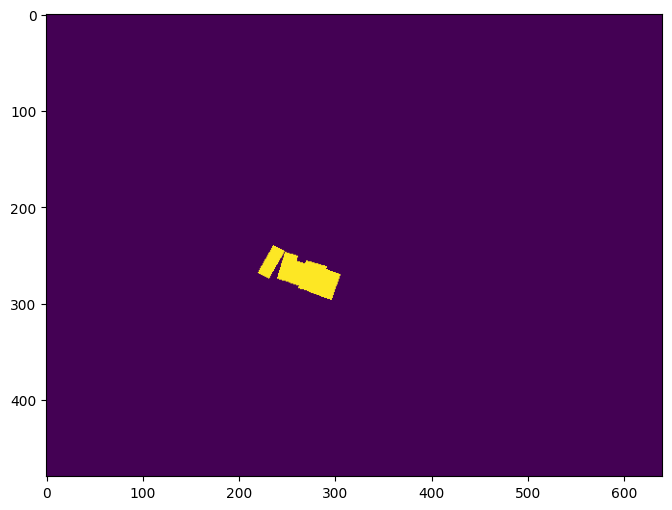

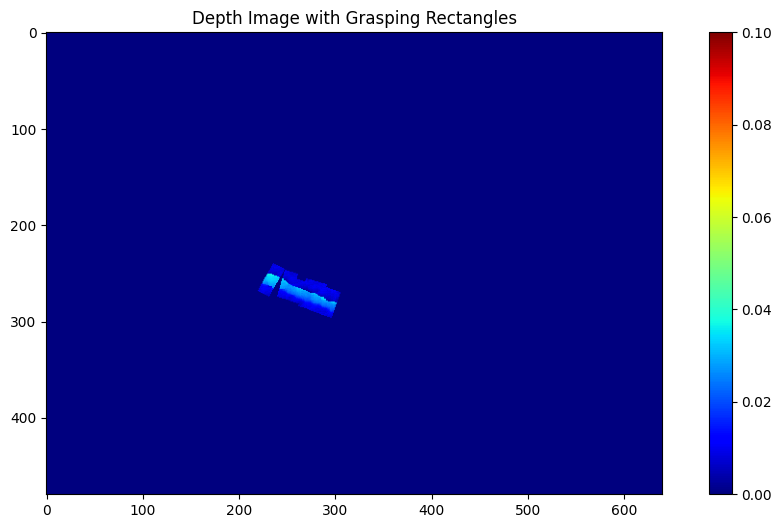

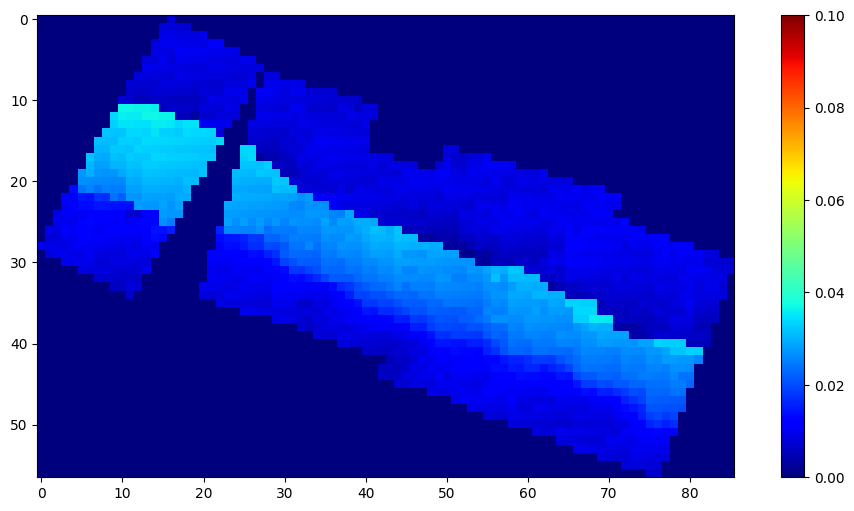

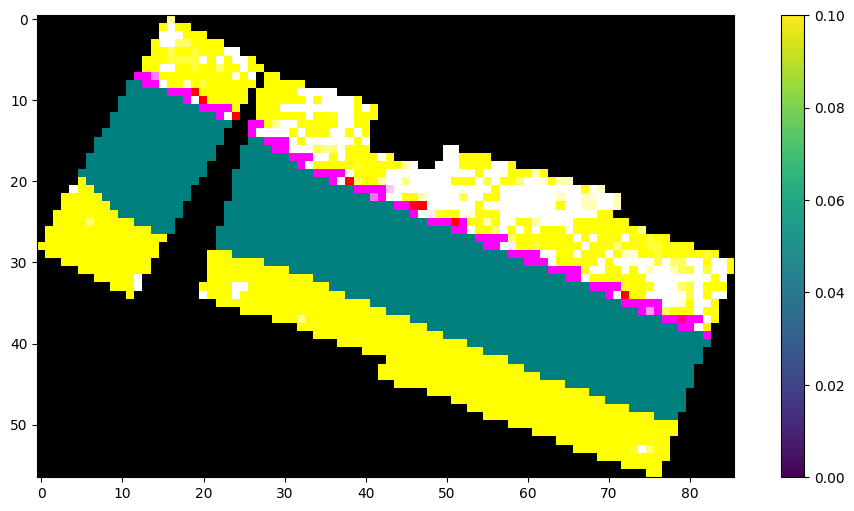

In [23]:
  #P3/P4 Inspect Output Single Image
  #THis is for actually cutting the images with the masks
  plt.figure(figsize=(12, 6))
  plt.imshow(images[20])
  plt.figure(figsize=(12, 6))
  plt.imshow(masks[20])

  plt.figure(figsize=(12, 6))
  plt.imshow((extracts[20]), cmap='jet', vmin=0, vmax=0.1)
  plt.colorbar()
  plt.title("Depth Image with Grasping Rectangles")
  plt.figure(figsize=(12, 6))
  plt.imshow((cropped_images[20]), cmap='jet', vmin=0, vmax=0.1)
  plt.colorbar()
  plt.figure(figsize=(12, 6))
  plt.imshow((cropped_images_yuv[20]), vmin=0, vmax=0.1)
  plt.colorbar()

In [ ]:
#P3/P4 #Data Inspection, used for generating video, LONG RUNTIME ON JS2 (90s)
  #print("New RGB-D Shape:", rgbd_new.shape)  # Expected output: (480, 640, 4)

  # Extract RGB and Depth for visualization
# i=0
# for items in RGBDtiff:
#   rgbd_new = RGBDtiff[i]
#   rgb_new = rgbd_new[:, :, :3]
#   depth_new = rgbd_new[:, :, 3]
#   plt.figure(figsize=(12, 6))
#   plt.imshow(extracts[i])
#   plt.figure(figsize=(12, 6))
#   plt.figure(figsize=(15, 5))
#   plt.subplot(1, 3, 1)
#   plt.imshow(cropped_images[i] , cmap='jet', vmin=0, vmax=0.1)
#   plt.colorbar()
#   plt.title("Depth Image")
#   plt.subplot(1, 3, 2)
#   plt.imshow((image_recon[i]) ,cmap='jet', vmin=0, vmax=0.1)
#   plt.colorbar()
#   plt.title("Reconstructed Depth Image")
#   i=i+1


## P5
Point Cloud Visualization

(480, 640, 4)


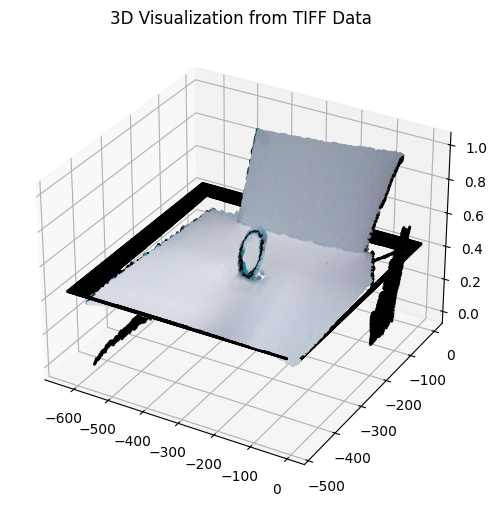

In [24]:
#P5
#Point Cloud Visualization
import tifffile as tiff
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# loading TIFF file
image_data = tiff.imread("/content/hw2/data/02/pcd0127_RGBD.tiff") #choose which image you want to plot
#the corresponding integer for 'reconstructed = image_recon[xx] is what is after the 1 in 145 i.e. 45'

#Checking shape
print(image_data.shape)

rgb = image_data[..., :3]  # RGB data
depth = image_data[..., 3]  # Depth map

h, w = depth.shape
x, y = np.meshgrid(np.arange(w), np.arange(h))

#normalizing depth for better scaling
normalized_depth = (depth - np.min(depth)) / (np.max(depth) - np.min(depth))

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(-1*x, -1*y, normalized_depth, c=rgb.reshape(-1, 3) / 255.0, s=1) #sign change for proper orientation

ax.set_title('3D Visualization from TIFF Data')
plt.show()


#plotting in an interactive 3d plot
import plotly.graph_objects as go

fig = go.Figure(data=[go.Surface(z=normalized_depth, surfacecolor=rgb[..., 0])])
fig.update_traces(colorscale='gray')
fig.show()


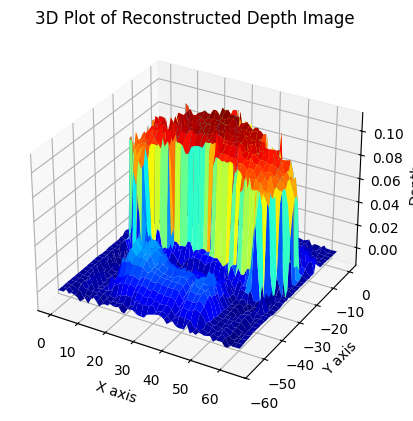

In [25]:
# PCA whitened data PLOTTING

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

reconstructed = image_recon[27]
#the corresponding integer for 'reconstructed = image_recon[xx] is what is after the 1 in 145 i.e. 45'

#creating a meshgrid
X, Y = np.meshgrid(np.arange(reconstructed.shape[1]), np.arange(reconstructed.shape[0]))

#plotting the surface
ax.plot_surface(X, -1*Y, reconstructed, cmap='jet')

ax.set_title('3D Plot of Reconstructed Depth Image')
ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')
ax.set_zlabel('Depth')

plt.show()

z = reconstructed

#creating a meshgrid for the image coordinates
X, Y = np.meshgrid(np.arange(z.shape[1]), np.arange(z.shape[0]))

#normalizing the depth values for better visualization
normalized_depth = (z - np.min(z)) / (np.max(z) - np.min(z))

#creating the surface plot of the reconstructed data
fig = go.Figure(data=[go.Surface(z=normalized_depth, x=-1*X, y=Y, surfacecolor=normalized_depth)])
fig.update_traces(colorscale='gray')
fig.update_layout(title='3D Plot of Reconstructed Depth Image', scene=dict(
                    xaxis_title='X axis',
                    yaxis_title='Y axis',
                    zaxis_title='Depth'))
fig.show()